## Анализ данных о Нобелевских лауреатах

### **Контекст проекта**
В этом задании мы будем работать с датасетом о лауреатах Нобелевской премии. Ваша задача — распарсить и проанализировать эти данные, ответив на ключевые вопросы о закономерностях вручения премий, демографических характеристиках лауреатов и исторических тенденциях.

### **Этап 1: Подготовка данных**

**Задача:** На этом этапе вам надо собрать структурированный список словарей с информацией о лауреатах и призах. Приведем начало нужного нам датасета.

``` {code:python}
[{'id': '745',
  'name': 'A. Michael Spence',
  'gender': 'male',
  'birth_year': 1943,
  'country_birth': 'USA',
  'country_now': 'USA',
  'prizes_relevant': [{'prize_amount': 10000000,
    'prize_amount_adjusted': 15547541,
    'award_year': 2001,
    'category_en': 'Economic Sciences',
    'prize_status': 'received'}],
  'type_': 'person'},
 {'id': '102',
  'name': 'Aage N. Bohr',
  'gender': 'male',
  'birth_year': 1922,
  'country_birth': 'Denmark',
  'country_now': 'Denmark',
  'prizes_relevant': [{'prize_amount': 630000,
    'prize_amount_adjusted': 4304697,
    'award_year': 1975,
    'category_en': 'Physics',
    'prize_status': 'received'}],
  'type_': 'person'}]
  ```

Поскольку информация о лауреатах-людях и лауреатах-организациях структурирована по-разному, а также из-за того, что часть полей в json могут отсутстввовать, необходимо реализовать функции для процессинга словарей, которые будут достаточно обобщаемыми для обоих типов данных.

**Что нужно сделать:**

На входе информация о конкретном лауреате представляет из себя кучу вложенных друг в друга словарей. Из этой структуры нам надо получить плоский словарь вида {atribute: value}, где atribute --- это один из небольшого множества интересных нам атрибутов. При этом в исходном файле 
1. пути к атрибутам могут иметь разную длину
2. атрибуты могут отсутствовать
3. атрибуты могут нуждаться в дополнительной обработке (например, поле id в исходных словарях записано как строка.)

Поскольку наивная реализация такого обработчика оказывается довольно громоздкой, вам нужно создать файл json_dict_processing.py, в котором реализован высокоуровневый функционал для решения задачи "обработать вложенный json-словарь"

Главное требование к интерфейсу: 
по (вложенному) словарю о лауреате и конфигу (см ниже) надо получить плоский словарь вида {atribute: value}.

Достичь этого можно, например, таким набором функций

* `extract_nested_value(obj, keys)` - извлекает значение из вложенных структур данных по цепочке ключей

* `process_dictionary_with_config(dictionary, config)` - обрабатывает один словарь согласно словару-конфигу (формат конфига см ниже.)

* `process_list_of_dicts_with_config(list_of_dicts, config)` - обрабатывает список словарей, эта функция нужна чтобы обработать список призов.

* `create_processor(config, list_processor=False)` - создает готовый процессор с предзагруженной конфигурацией. В случае, если list_processor == True, внутрь процессора подается process_list_of_dicts_with_config, иначе process_dictionary_with_config.

**Замечание насчет последней функции.**

Планируемое применение этой функции примерно такое:
`laureate_processor = create_processor(PERSON_CONFIG, list_processor=False)`

То есть, create_processor возвращает функцию, которая реализует функционал process_dictionary_with_config но с уже заполненным конфигом. Это повышает читаемость кода и снижает риск перепутать конфиги из-за дублирования кода.


Помимо этого нужно создать файлы-конфиги для данных по призам, лауреатам-людям, и лауреатам-организациям.

КОНФИГ для функций process_dictionary_with_config и process_list_of_dicts_with_config имеет следующий вид
```python
  {'атрибут_который_берем_сырым': ['путь', 'к', 'данным'],  # или
  'атрибут_который_нужно_обработать': (['путь', 'к', 'данным'], функция_обработки)}
  ```
В случае, если атрибут можно взять в итоговый датасет сырым, в values() словаря-конфига будет список path_list.
Если же атрибут еще надо обработать, для него в поле config[attribute] будет tuple вида (path_list, function).

Примеры атрибутов, которые можно взять сырыми: имя, размер приза. Примеры атрибутов, которые нужно обработать: год вручения приза (в сырых данных есть только полная дата, записанная как строка)

После того, как будет создан core.py, создайте конфиги laureates_configs.py и prizes_configs.py

Постарайтесь провалидировать код с помощью assert-ов, вызываемых в ноутбуке или в .py-файлах.

пример использования: 

assert 1 == True

**Валидация**

В вашем случае assert должен взять простой словарик с одним вложенным полем и какой-нибудь конфиг-файл.
Также убедитесь, что при обработке данных собственно по лауреатам в них нет странностей (смотрите ниже) 

**Атрибуты для ПРИЗА (CONFIG_PRIZE, prizes_configs.py)**

- `prize_amount` - сумма приза → `prizeAmount`
- `prize_amount_adjusted` - скорректированная сумма приза → `prizeAmountAdjusted`
- `award_year` - год вручения приза (преобразуется в целое число) → `awardYear`
- `category_en` - категория на английском → `category.en`
- `prize_status` - статус приза → `prizeStatus`

**Атрибуты для ЧЕЛОВЕКА-ЛАУРЕАТА (CONFIG_PERSON, laureates_configs.py)**

- `id` - уникальный идентификатор → `id`
- `name` - имя лауреата → `knownName.en`
- `gender` - пол → `gender`
- `birth_year` - год рождения (извлекается из даты) → `birth.date`
- `country_birth` - страна рождения → `birth.place.country.en`
- `country_now` - текущая страна → `birth.place.countryNow.en`
- `prizes_relevant` - список призов лауреата → `nobelPrizes` (обрабатывается процессором призов, который вы задаете в конфиге для призов)

**Атрибуты для ОРГАНИЗАЦИИ-ЛАУРЕАТА (CONFIG_ORG, laureates_configs.py)**

- `id` - уникальный идентификатор → `id`
- `name` - название организации → `orgName.en`
- `founded_year` - год основания (извлекается из даты) → `founded.date`
- `country_founded` - страна основания → `founded.place.country.en`
- `country_now` - текущая страна → `founded.place.countryNow.en`
- `prizes_relevant` - список призов организации → `nobelPrizes` (обрабатывается процессором призов, который вы задаете в конфиге для призов)

**Вспомогательные функции:**

- `process_year(year_string)` - извлекает год из строки даты (формат "YYYY-MM-DD"). Функция находится в файле laureates_configs.py
- `prize_processor()` - создает процессор для обработки списков призов. Функция находится в файле prizes_configs.py
- `person_processor()` - создает процессор для данных о людях-лауреатах. Функция находится в файле laureates_configs.py
- `org_processor()` - создает процессор для данных об организациях-лауреатах. Функция находится в файле laureates_configs.py

In [ ]:
import requests
from core import process_laureate


URL_LAUREATES = f'https://api.nobelprize.org/2.1/laureates?limit=1200'


# Скачиваем данные
laureates_response = requests.get(URL_LAUREATES)
laureates = laureates_response.json()


# Обрабатываем лауреатов
laureates_data = []
for laureate in laureates['laureates']:
    processed = process_laureate(laureate)
    laureates_data.append(processed)


# Проверим первые несколько записей
for l in laureates_data[:3]:
    print(l)

{'id': '745', 'name': 'A. Michael Spence', 'gender': 'male', 'birth_date': '1943-00-00', 'country_birth': 'USA', 'country_now': 'USA', 'prizes': [{'prize_amount': 10000000, 'prize_amount_adjusted': 15547541, 'award_year': 2001, 'category_en': 'Economic Sciences', 'prize_status': 'received'}], 'birth_year': 1943, 'type_': 'person'}
{'id': '102', 'name': 'Aage N. Bohr', 'gender': 'male', 'birth_date': '1922-06-19', 'country_birth': 'Denmark', 'country_now': 'Denmark', 'prizes': [{'prize_amount': 630000, 'prize_amount_adjusted': 4304697, 'award_year': 1975, 'category_en': 'Physics', 'prize_status': 'received'}], 'birth_year': 1922, 'type_': 'person'}
{'id': '779', 'name': 'Aaron Ciechanover', 'gender': 'male', 'birth_date': '1947-10-01', 'country_birth': 'British Protectorate of Palestine', 'country_now': 'Israel', 'prizes': [{'prize_amount': 10000000, 'prize_amount_adjusted': 14874529, 'award_year': 2004, 'category_en': 'Chemistry', 'prize_status': 'received'}], 'birth_year': 1947, 'type

In [2]:
import laureates_configs
print(dir(laureates_configs))

['CONFIG_ORG', 'CONFIG_PERSON', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'get_year_from_date', 'process_one_item', 'process_orgs', 'process_persons', 'process_prizes']


In [ ]:
from laureates_configs import process_orgs, process_persons


def get_laureate_data(laureate):
    """
    Определяет тип лауреата и обрабатывает данные соответствующим процессором
    
    Args:
        laureate: dict с данными лауреата
        
    Returns:
        dict с обработанными данными и добавленным полем 'type_' ('person' или 'org')
    """
    if 'knownName' in laureate:  # Если есть поле knownName → человек
        processed = process_persons(laureate)
        processed['type_'] = 'person'
    elif 'orgName' in laureate:  # Если есть поле orgName → организация
        processed = process_orgs(laureate)
        processed['type_'] = 'org'
    else:
        # На всякий случай, если структура непредвиденная
        processed = laureate.copy()
        processed['type_'] = 'unknown'
    
    return processed


# Обрабатываем всех лауреатов
laureates_data = [get_laureate_data(l) for l in laureates['laureates']]


# Создаем списки с разными типами для проверки, что оба вида лауреатов обрабатываются корректно
people_examples = []
org_examples = []


for l in laureates_data:
    if l['type_'] == 'person' and len(people_examples) < 2:
        people_examples.append(l)
    elif l['type_'] == 'org' and len(org_examples) < 2:
        org_examples.append(l)
    if len(people_examples) == 2 and len(org_examples) == 2:
        break

# Выводим примеры
print("Примеры людей:")
for p in people_examples:
    print(p)
    
print("\n")

print("Примеры организаций:")
for o in org_examples:
    print(o)

Примеры людей:
{'id': '745', 'name': 'A. Michael Spence', 'gender': 'male', 'birth_date': '1943-00-00', 'country_birth': 'USA', 'country_now': 'USA', 'prizes': [{'prize_amount': 10000000, 'prize_amount_adjusted': 15547541, 'award_year': 2001, 'category_en': 'Economic Sciences', 'prize_status': 'received'}], 'birth_year': 1943, 'type_': 'person'}
{'id': '102', 'name': 'Aage N. Bohr', 'gender': 'male', 'birth_date': '1922-06-19', 'country_birth': 'Denmark', 'country_now': 'Denmark', 'prizes': [{'prize_amount': 630000, 'prize_amount_adjusted': 4304697, 'award_year': 1975, 'category_en': 'Physics', 'prize_status': 'received'}], 'birth_year': 1922, 'type_': 'person'}


Примеры организаций:
{'id': '509', 'name': 'American Friends Service Committee', 'founded_date': '1917-00-00', 'country_founded': 'USA', 'country_now': 'USA', 'prizes': [{'prize_amount': 146115, 'prize_amount_adjusted': 3685518, 'award_year': 1947, 'category_en': 'Peace', 'prize_status': 'received'}], 'founded_year': 1917, 't



### **Этап 2: EDA лауреатов**

EDA или Exploratory Data Analysis - первый шаг при работе с любыми данными.

Чтобы начать работать с этой секцией, проведите проведите чисто технический анализ собранных данных.

1. Сколько всего записей?
2. Все ли значения полей заполнены?
3. Если нет, сколько пропусков в каждом из полей? Выведите ответ на этот вопрос в формате `{'field_name': missing_values}`. А какая доля пропусков?
5. Каковы максимальные и минимальные значения поля id и каким годам награждения они соответствуют? Есть ли записи с повторяющимися id? Есть ли пары айди, которые в отсортированном массиве айдишников различаются более, чем на один? 

При реализации ответов на эти вопросы, пользуйтесь теми же принципами, что описаны выше. Можете начать с плохого хакерского кода, однако в таком случае в маркдауне пропишите, как будете его обобщать и разносить по функциям и модулям. (об этом ниже)

В основном EDA пользуйтесь аккуратным кодом, разбитым на функции и файлы.

In [7]:
from eda_utils import count_missing, get_min_max_id_year, find_duplicate_ids, find_id_gaps

# пропуски
missing_counts, missing_ratio = count_missing(laureates_data)
print("Сколько пропусков в каждом поле:", missing_counts)
print("Доля пропусков в каждом поле:", missing_ratio)

# минимальный и максимальный id
min_id, max_id = get_min_max_id_year(laureates_data)
print("Минимальный id и год награждения:", min_id)
print("Максимальный id и год награждения:", max_id)

# повторяющиеся id
duplicates = find_duplicate_ids(laureates_data)
print("Повторяющиеся id:", duplicates)

# разрывы в id
gaps = find_id_gaps(laureates_data)
print("Пары id с разрывом больше 1:", gaps)


Сколько пропусков в каждом поле: {'country_birth': 4, 'country_now': 8, 'country_founded': 4, 'founded_date': 1, 'founded_year': 1}
Доля пропусков в каждом поле: {'country_birth': 0.0039, 'country_now': 0.0079, 'country_founded': 0.0039, 'founded_date': 0.001, 'founded_year': 0.001}
Минимальный id и год награждения: (1, 1901)
Максимальный id и год награждения: (1060, 2025)
Повторяющиеся id: []
Пары id с разрывом больше 1: [(6, 8), (93, 95), (169, 172), (255, 257), (468, 470), (503, 505), (520, 523), (541, 543), (569, 571), (590, 592), (594, 596), (597, 600), (610, 613), (615, 617), (631, 633), (635, 637), (645, 647), (655, 657), (783, 786), (787, 789), (858, 861), (896, 903), (949, 958), (1009, 1011)]



Поскольку это курс по Python, а не по статистике или визуализации данных, мы не задаем жесткие рамки того, что вы должны проанализировать.
Однако это отличная возможность представить себя в роли разработчика базы данных или, например, библиотеки pandas.

В коде нужно соблюдать следующие правила:

1. должны быть реализованы  несколько способов работы с данными (среднее/медианное/максимальное значение метрики, количество примеров, вывод топ-N объектов по значению метрики).
2. анализ выбранных вами тем должен включать в себя анализ метрик в тотале, по категориям и в динамике по годам или десятилетиям.
3. проанализировать стоит 2-3 темы. Вы можете использовать темы ниже или взять свои.
2. вывод ноутбука должен быть понятен обывателю. Это может быть визуализация в matplotlib/seaborn. Сопровождайте вывод markdown-ячейками с вашими  мыслями, пояснениями и инсайтами, которые удалось извлечь.
3. Нельзя использовать pandas и numpy, но можно вдохновляться их интерфейсом и функционалом при дизайне ваших функций.


Из пункта 2 следует, что вам придется работать не только с атрибутами лауреатов, но и самих призов.
Информацию о призах нужно доставать и записывать как атрибут уже лауреата. Функции, работающие с призами (например, факт того, что лауреат отказался от какого-то из призов) можно реализовать в ноутбуке, но если вы создаете более общие вспомогательные функции, выносите их в отдельные модули.

Мы рекомендуем следующую структуру кода:

* `dataset_helpers.py` в котором реализованы фильтрация списка словарей (плоских) по условиям (аналог sql-ного where), а также аналог sql-ного групбая. А также функция для применения агрегаций к списку словарей
* `aggregations.py` в котором реализованы функции расчета среднего/медианы/других эвристик и мб вывод топ n-значений по какой-то метрике.
* `atribute_manager.py` в котором реализован переиспользуемый интерфейс для добавления (и мб удаления) полей.

Замечание насчет group-by. 

На игрушесном примере она может работать примерно так:
```
    Входные данные: [
        {'name': 'Alice', 'country': 'USA', 'age': 25},
        {'name': 'Bob', 'country': 'UK', 'age': 30},
        {'name': 'Charlie', 'country': 'USA', 'age': 25}
    ]
    
    group_by_attributes(data, ['country', 'age']) → {
        ('USA', 25): [
            {'name': 'Alice', 'country': 'USA', 'age': 25},
            {'name': 'Charlie', 'country': 'USA', 'age': 25}
        ],
        ('UK', 30): [
            {'name': 'Bob', 'country': 'UK', 'age': 30}
        ]
    }
```

Замечание насчет agregations.py
1. Агрегации соответственно должны применяться к спискам вида [
    {'name': 'Alice', 'country': 'USA', 'age': 25},
    {'name': 'Charlie', 'country': 'USA', 'age': 25}
]
2. Пользуйтесь модулем statistics из стандартной библиотеки питона.


Эта структура одна из возможных для организации вашего кода, главное, чтобы эти достаточно общие функции блыи переиспользованы

При анализе данных вам понадобятся более конкретные функции, например filter_by_num_prizes или output_metric_by_category. Их пишите прямо в ноутбуке и сопровождайте коментами.

Ниже мы приводим некоторые примеры вопросов, которые может быть интересно задать к данным, но если у вас есть желание, можете поисследовать датасет с любой интересной вам стороны!


**2.1. Топ-статистика по странам**
- Определите топ-5 стран по общему количеству лауреатов
- Постройте аналогичные рейтинги отдельно по категориям (физика, химия, медицина и т.д.)

**2.2. Возраст при награждении**
- Рассчитать средний возраст лауреатов на момент получения **первого** приза. Рассмотрите только лауреатов-людей.
- Исследуйте, как средний возраст получения первого приза различается по категориям
- Различаются ли средний и медианный возрасты? 

**2.3. Гендерное распределение**
- Как менялось количество женщин-лауреатов по десятилетиям?
- Сравните распределение лауреаток по категориям. Выведите значения суммарно за все годы и по декадам.
- В какой из категорий больше всего женщин лауреаток изначально и в последние пару десятилетий?

**2.4. Миграции лауреатов**
- У скольки лауреатов исходная страна и страна на момент вручения нобелевской премии различаются? Всегда ли это различие объясняется миграцией? Добавьте вспомогательное поле 'country_of_origin_adjusted_for_migration', чтобы различие между этим полем и страной на момент вручения объяснялось миграцией.
- Выявите страны с наибольшей долей "оттекших" и "притекших" лауреатов.
- Есть ли оттоки среди организаций?

**2.5. Многократные лауреаты**
- Найдите лауреатов, получившие больше одного приза. Кто получил больше 2 раз? 
- Совпадает ли категория второго приза с первой?  
- Сколько в среднем времени прошло между получением первой и второй премии?

**2.6 Отказы от премий**
- Определите, в каких категориях чаще отказывались от премий?
- Есть ли отказы среди организаций?



In [8]:
from dataset_helpers import group_by_attributes, filter_by_field
from aggregations import top_n
from attribute_manager import add_field
from statistics import mean, median

In [9]:
# Первые 5 стран по количеству лауреатов

# Фильтруем только записи с заполненной страной рождения
laureates_with_country = [l for l in laureates_data if l.get('country_birth') is not None]

# Группируем по стране рождения
grouped = group_by_attributes(laureates_with_country, ['country_birth'])

# Считаем количество лауреатов в каждой стране
country_counts = []
for k, v in grouped.items():
    country_counts.append({
        'country': k[0],
        'count': len(v)
    })

# Берём топ 5
top5_countries = top_n(country_counts, 'count', n=5)
print("Топ 5 стран по количеству лауреатов:")
for c in top5_countries:
    print(f"{c['country']}: {c['count']} лауреатов")

Топ 5 стран по количеству лауреатов:
USA: 295 лауреатов
United Kingdom: 94 лауреатов
Germany: 80 лауреатов
France: 60 лауреатов
Japan: 30 лауреатов


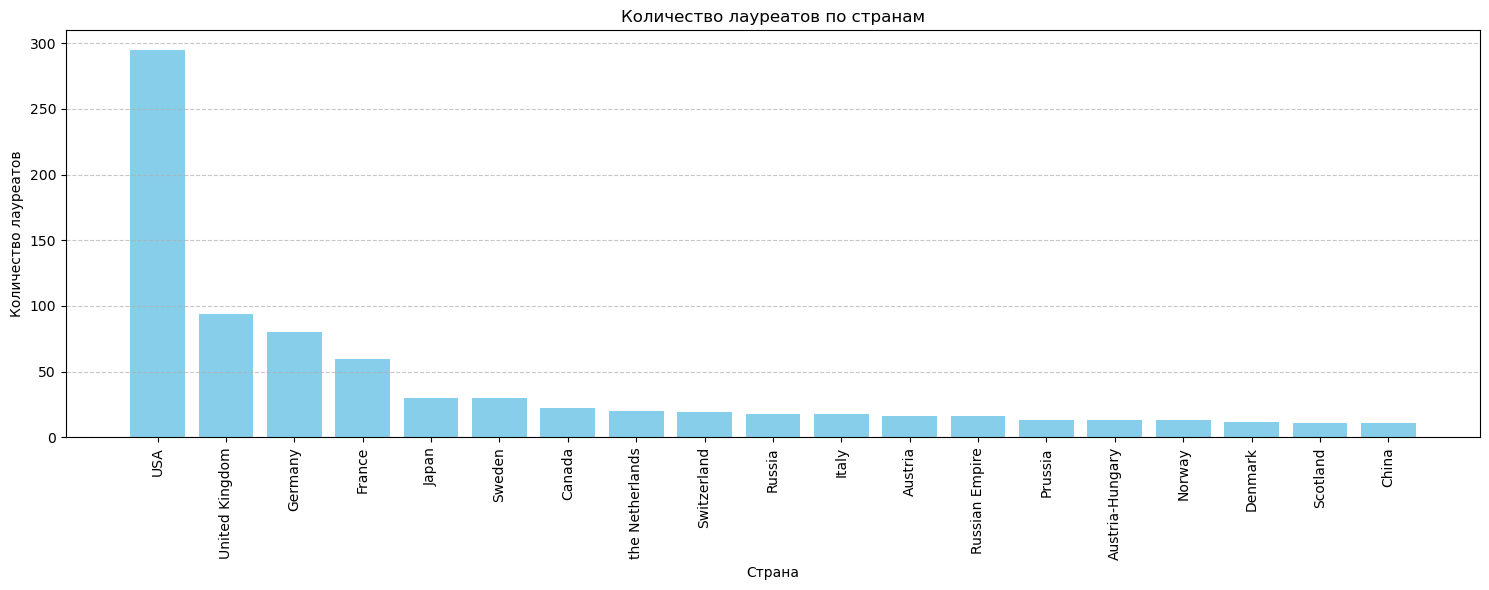

In [10]:
import matplotlib.pyplot as plt

# Фильтруем только записи с указанной страной
laureates_with_country = [l for l in laureates_data if l.get('country_birth') is not None]

# Группируем по стране рождения
grouped = group_by_attributes(laureates_with_country, ['country_birth'])

# Считаем количество лауреатов в каждой стране
country_counts = []
for k, v in grouped.items():
    country_counts.append({
        'country': k[0],
        'count': len(v)
    })

# Сортируем страны по количеству лауреатов
country_counts_sorted = sorted(country_counts, key=lambda x: x['count'], reverse=True)

# Оставляем только страны с > 10 лауреатами
country_counts_filtered = [c for c in country_counts_sorted if c['count'] > 10]

# Данные для графика
countries = [c['country'] for c in country_counts_filtered]
counts = [c['count'] for c in country_counts_filtered]

# Определяем топ 5 стран для подсветки
colors = ['orange' if c in top5_countries else 'skyblue' for c in countries]

# Строим график
plt.figure(figsize=(15, 6))
plt.bar(countries, counts, color=colors)
plt.xlabel("Страна")
plt.ylabel("Количество лауреатов")
plt.title("Количество лауреатов по странам")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Средний и медианный возраст при первом призе
people = [l for l in laureates_data if l['type_'] == 'person']


ages_first_prize = []
for p in people:
    prizes = sorted(p.get('prizes', []), key=lambda x: x['award_year'])
    if prizes and p.get('birth_year'):
        age = prizes[0]['award_year'] - p['birth_year']
        ages_first_prize.append(age)


print("Возраст при первом призе:")
print("Средний возраст:", round(mean(ages_first_prize), 2))
print("Медианный возраст:", median(ages_first_prize))

Возраст при первом призе:
Средний возраст: 60.44
Медианный возраст: 61.0


In [ ]:
# Женщины лауреаты по десятилетиям

# Добавляем десятилеите
def get_decade(record):
    if record.get('prizes'):
        first_year = min(p['award_year'] for p in record['prizes'] if p.get('award_year'))
        return (first_year // 10) * 10
    return None


people = add_field(people, 'decade', get_decade)

# Группируем по десятилетию и по полу
grouped = group_by_attributes(people, ['decade', 'gender'])

# Считаем количество женщин в каждом десятилетии
female_by_decade = {}
for k, v in grouped.items():
    decade_value, gender_value = k
    if gender_value == 'female':
        female_by_decade[decade_value] = len(v)

print("Количество женщин-лауреатов по десятилетиям:")
for decade, count in sorted(female_by_decade.items()):
    print(f"{decade}-е годы: {count}")

Количество женщин-лауреатов по десятилетиям:
1900-е годы: 3
1920-е годы: 2
1930-е годы: 3
1940-е годы: 3
1960-е годы: 3
1970-е годы: 4
1980-е годы: 4
1990-е годы: 7
2000-е годы: 11
2010-е годы: 13
2020-е годы: 14


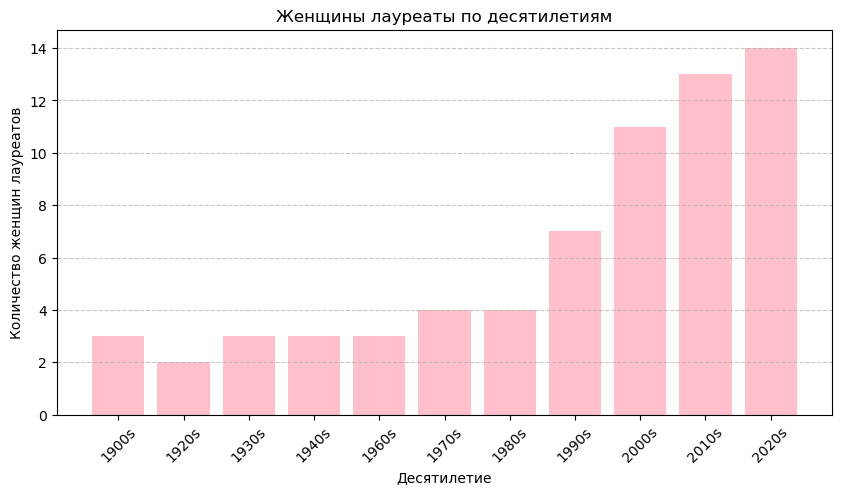

In [14]:
import matplotlib.pyplot as plt

# Сортируем десятилетия
decades = sorted(female_by_decade.keys())
counts = [female_by_decade[d] for d in decades]

# Создаем график
plt.figure(figsize=(10, 5))
plt.bar([str(d) + "s" for d in decades], counts, color='pink')
plt.xlabel("Десятилетие")
plt.ylabel("Количество женщин лауреатов")
plt.title("Женщины лауреаты по десятилетиям")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from statistics import mean

# Берём только людей и организаций, у которых есть призы
laureates_with_prizes = [l for l in laureates_data if l.get('prizes')]

# Найдём лауреатов с более чем одним призом
multi_prize_laureates = [l for l in laureates_with_prizes if len(l['prizes']) > 1]

print("Количество лауреатов с более чем одним призом:", len(multi_prize_laureates))

# Кто получил больше 2 раз
more_than_two = [l for l in multi_prize_laureates if len(l['prizes']) > 2]
print("Лауреаты с более чем двумя призами:", len(more_than_two))

# Совпадает ли категория второго приза с первой
same_category_count = 0
time_gaps = []

for l in multi_prize_laureates:
    # сортируем призы по году вручения
    prizes_sorted = sorted(l['prizes'], key=lambda x: x['award_year'])
    if len(prizes_sorted) >= 2:
        first_prize = prizes_sorted[0]
        second_prize = prizes_sorted[1]
        
        # проверка совпадения категории
        if first_prize.get('category_en') == second_prize.get('category_en'):
            same_category_count += 1
        
        # разница во времени между первым и вторым призом
        gap = second_prize['award_year'] - first_prize['award_year']
        time_gaps.append(gap)

print("Количество лауреатов, у которых категория второго приза совпадает с первым:", same_category_count)

# Среднее время между первым и вторым призом
if time_gaps:
    avg_gap = round(mean(time_gaps), 2)
else:
    avg_gap = None

print("Среднее количество лет между первым и вторым призом:", avg_gap)

Количество лауреатов с более чем одним призом: 7
Лауреаты с более чем двумя призами: 1
Количество лауреатов, у которых категория второго приза совпадает с первым: 5
Среднее количество лет между первым и вторым призом: 18.43


In [16]:
from collections import defaultdict

# Добавляем поле country_origin
for l in laureates_data:
    birth = l.get('country_birth')
    now = l.get('country_now')
    
    if birth is None or now is None:
        l['country_origin'] = None
    else:
        # если родная страна совпадает с текущей, поле равно стране
        if birth == now:
            l['country_origin'] = birth
        else:
            # если страны разные, указываем страну рождения
            l['country_origin'] = birth

# Считаем количество лауреатов, у которых страна рождения и страна вручения различаются
migration_count = 0
for l in laureates_data:
    birth = l.get('country_birth')
    now = l.get('country_now')
    if birth and now and birth != now:
        migration_count += 1

print("Количество лауреатов, у которых страна рождения и страна вручения различаются:", migration_count)

# Выявляем отток и приток для стран
outflow = defaultdict(int)
inflow = defaultdict(int)

for l in laureates_data:
    birth = l.get('country_birth')
    now = l.get('country_now')
    if birth and now and birth != now:
        outflow[birth] += 1
        inflow[now] += 1

# Топ-5 стран по оттоку и притоку
top_outflow = sorted(outflow.items(), key=lambda x: x[1], reverse=True)[:5]
top_inflow = sorted(inflow.items(), key=lambda x: x[1], reverse=True)[:5]

print("Топ-5 стран по оттоку лауреатов:", top_outflow)
print("Топ-5 стран по притоку лауреатов:", top_inflow)

# Проверяем миграции среди организаций
org_migration_count = 0
for l in laureates_data:
    if l['type_'] == 'org':
        birth = l.get('country_birth')
        now = l.get('country_now')
        if birth and now and birth != now:
            org_migration_count += 1

print("Количество организаций, у которых страна основания и страна вручения различаются:", org_migration_count)


Количество лауреатов, у которых страна рождения и страна вручения различаются: 113
Топ-5 стран по оттоку лауреатов: [('Russian Empire', 16), ('Prussia', 13), ('Germany', 13), ('Austria-Hungary', 13), ('USSR', 7)]
Топ-5 стран по притоку лауреатов: [('Poland', 22), ('Germany', 17), ('Russia', 11), ('Israel', 6), ('Czech Republic', 6)]
Количество организаций, у которых страна основания и страна вручения различаются: 0


---------

## Бонусное задание на +2 балла


### Лингвистический анализ мотиваций**

**5.1. Анализ текстов мотиваций**
- Соберите корпус текстов мотиваций вручения премий. Для этого измените конфиг обработки призов.
- Выделите самые частые топ-50 слов. Какие из этих слов самые частые в принципе в английском языке (такие, как for, the и другие), а какие кажутся важными именно в контексте вручения Нобелевской премии (например, 'chemistry')?
- Самые частые слова, которые также являются частыми во всем английском языке занесите в отдельный конфиг-файл под названием `stopwords.py`. Вычистите их из текстов. Какие слова являются самыми частыми теперь? Сравните множества топ-10 самых частых слов по разным категориям


- Если есть желание, посчитайте TF-IDF + сравнените топ слов по этой метрике с просто самыми популярными словами)

In [18]:
url = "https://api.nobelprize.org/2.1/laureates?limit=1200"
response = requests.get(url)
data = response.json()

motivations = []

for laureate in data['laureates']:
    for prize in laureate.get('nobelPrizes', []):
        motivation = prize.get('motivation')
        if motivation and isinstance(motivation, dict):
            text = motivation.get('en') 
            if text:
                motivations.append(text.lower())

print(f"{len(motivations)} мотиваций")

1026 мотиваций


In [20]:
import re
from collections import Counter
all_text = " ".join(motivations)  # соединяем все тексты в один большой
words = re.findall(r'\b[a-z]+\b', all_text)  # берём только английские слова
word_counts = Counter(words)  # считаем, сколько раз встречается каждое слово
top50_words = word_counts.most_common(100) # пока выведу 100, чтобы больше отсеять
print("Топ-100 слов:", top50_words)

Топ-100 слов: [('of', 1285), ('the', 1243), ('for', 1138), ('and', 662), ('in', 446), ('their', 391), ('his', 376), ('to', 276), ('discovery', 208), ('discoveries', 169), ('a', 151), ('concerning', 121), ('development', 110), ('work', 106), ('on', 101), ('which', 99), ('with', 98), ('by', 82), ('theory', 74), ('contributions', 60), ('has', 59), ('structure', 58), ('that', 54), ('peace', 52), ('recognition', 48), ('economic', 45), ('human', 44), ('chemical', 43), ('as', 42), ('analysis', 42), ('new', 40), ('its', 39), ('pioneering', 38), ('an', 38), ('fundamental', 37), ('synthesis', 36), ('efforts', 35), ('between', 34), ('chemistry', 34), ('he', 34), ('studies', 31), ('through', 31), ('method', 30), ('her', 30), ('international', 29), ('especially', 29), ('methods', 29), ('having', 28), ('role', 27), ('research', 26), ('quantum', 26), ('cell', 26), ('nuclear', 26), ('system', 26), ('contribution', 26), ('s', 25), ('into', 24), ('investigations', 24), ('rights', 24), ('life', 23), ('me

In [21]:
# Стоп слова
STOPWORDS = {
    'of', 'the', 'for', 'and', 'in', 'their', 'his', 'to', 'a', 'concerning', 'on', 'which', 'with', 'by', 'has', 'that', 'as', 'its', 
    'an', 'between', 'he', 'through', 'her', 'having', 's', 'into', 'our', 'have', 'i', 'they', 'who',
    
}

In [22]:
filtered_words = [w for w in words if w not in STOPWORDS]  # оставляем только важные слова
filtered_counts = Counter(filtered_words)
top50_filtered = filtered_counts.most_common(50)
print("Топ-50 слов после удаления стоп-слов:", top50_filtered)

Топ-50 слов после удаления стоп-слов: [('discovery', 208), ('discoveries', 169), ('development', 110), ('work', 106), ('theory', 74), ('contributions', 60), ('structure', 58), ('peace', 52), ('recognition', 48), ('economic', 45), ('human', 44), ('chemical', 43), ('analysis', 42), ('new', 40), ('pioneering', 38), ('fundamental', 37), ('synthesis', 36), ('efforts', 35), ('chemistry', 34), ('studies', 31), ('method', 30), ('international', 29), ('especially', 29), ('methods', 29), ('role', 27), ('research', 26), ('quantum', 26), ('cell', 26), ('nuclear', 26), ('system', 26), ('contribution', 26), ('investigations', 24), ('rights', 24), ('life', 23), ('mechanism', 23), ('genetic', 22), ('high', 22), ('organic', 21), ('reactions', 21), ('invention', 20), ('important', 19), ('physics', 19), ('effect', 19), ('war', 19), ('atomic', 18), ('protein', 18), ('services', 18), ('power', 18), ('cells', 18), ('poetry', 18)]


In [23]:
# Словарь для хранения текстов по категориям
category_texts = {}

for laureate in data['laureates']:
    for prize in laureate.get('nobelPrizes', []):
        category_name = prize.get('category', {}).get('en', 'Unknown')
        motivation = prize.get('motivation')

        if motivation and isinstance(motivation, dict):
            text = motivation.get('en')
            if text:
                category_texts.setdefault(category_name, []).append(text.lower())  # добавляем текст

# Топ 10 слов по каждой категории
category_top_words = {}
for cat, texts in category_texts.items():
    all_cat_text = " ".join(texts)  # объединяем все тексты категории
    words_cat = [w for w in re.findall(r'\b[a-z]+\b', all_cat_text) if w not in STOPWORDS]  # слова без стоп-слов
    counts_cat = Counter(words_cat)  # считаем частоту слов
    category_top_words[cat] = counts_cat.most_common(10) 

for cat, top_words in category_top_words.items():
    print(f"\nТоп-10 слов в категории {cat}:", top_words)



Топ-10 слов в категории Economic Sciences: [('theory', 43), ('economic', 41), ('analysis', 35), ('contributions', 18), ('pioneering', 15), ('research', 13), ('markets', 10), ('financial', 8), ('empirical', 8), ('development', 8)]

Топ-10 слов в категории Physics: [('discovery', 99), ('development', 30), ('discoveries', 27), ('theory', 25), ('contributions', 22), ('quantum', 22), ('fundamental', 21), ('structure', 20), ('work', 20), ('physics', 19)]

Топ-10 слов в категории Chemistry: [('development', 52), ('discovery', 34), ('chemistry', 33), ('chemical', 31), ('work', 26), ('synthesis', 26), ('structure', 23), ('organic', 21), ('studies', 20), ('contributions', 17)]

Топ-10 слов в категории Literature: [('human', 19), ('life', 19), ('poetry', 18), ('poetic', 17), ('art', 16), ('great', 12), ('power', 11), ('narrative', 11), ('recognition', 10), ('epic', 10)]

Топ-10 слов в категории Peace: [('peace', 52), ('efforts', 35), ('work', 32), ('international', 25), ('rights', 23), ('war', 1

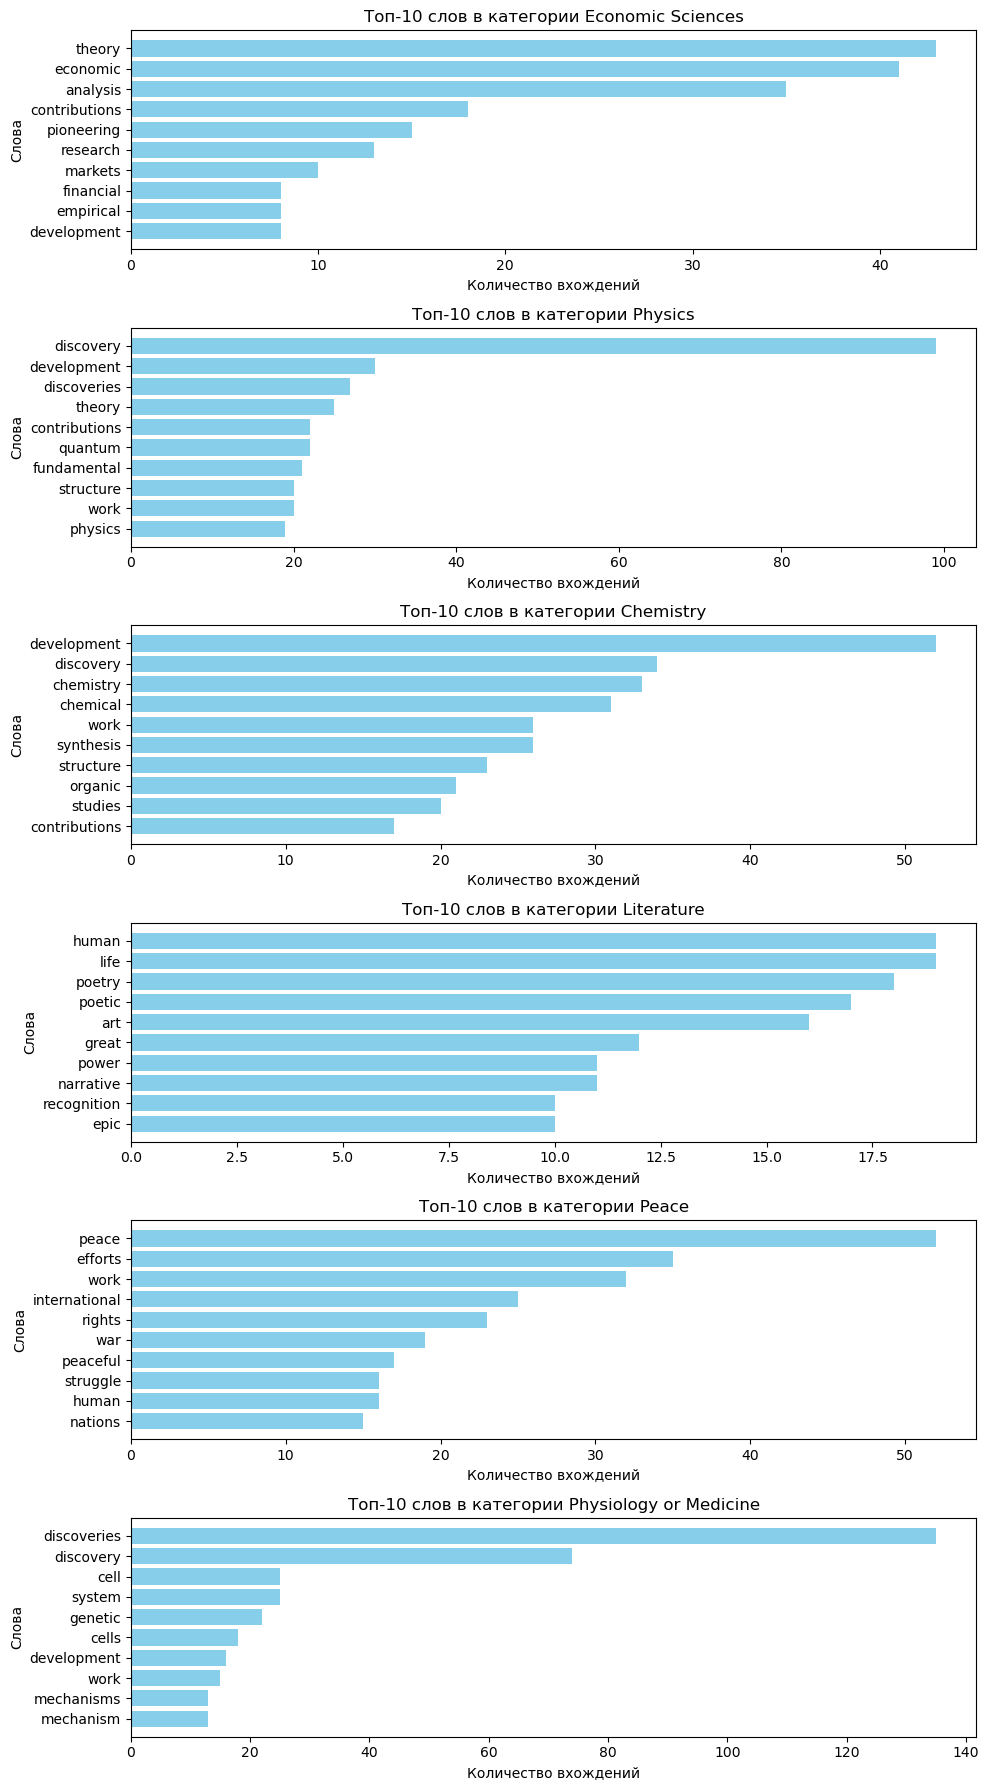

In [24]:
categories = list(category_top_words.keys())
num_categories = len(categories)

fig, axes = plt.subplots(num_categories, 1, figsize=(10, num_categories*3))

if num_categories == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    words, counts = zip(*category_top_words[cat])
    ax.barh(words[::-1], counts[::-1], color='skyblue') 
    ax.set_title(f"Топ-10 слов в категории {cat}")
    ax.set_xlabel("Количество вхождений")
    ax.set_ylabel("Слова")

plt.tight_layout()
plt.show()

In [ ]:
import math


# Функция для TF-IDF важных слов
def get_top10_tfidf_words(motivations, stopwords):
    """
    Считает TF-IDF для важных слов
    Возвращает топ-10 слов с TF-IDF
    """
    all_words_list = []
    for text in motivations:
        # разбиваем текст на слова и убираем стоп-слова
        words = [w.lower() for w in re.findall(r'\b[a-z]+\b', text) if w.lower() not in stopwords]
        all_words_list.append(words)

    # DF — в скольких документах встречается слово
    df_counts = {}
    for doc in all_words_list:
        for word in set(doc):
            df_counts[word] = df_counts.get(word, 0) + 1

    N = len(all_words_list)

    # суммарный TF-IDF
    tfidf_total = {}
    for doc in all_words_list:
        counts = Counter(doc)
        doc_len = len(doc)
        if doc_len == 0:
            continue
        for word, count in counts.items():
            tf = count / doc_len
            idf = math.log(N / (1 + df_counts[word]))
            tfidf_total[word] = tfidf_total.get(word, 0) + tf * idf

    # топ-10 слов
    top10 = [(word, round(score, 4)) for word, score in Counter(tfidf_total).most_common(10)]
    return top10


# Функция для TF-IDF стоп-слов
def get_top10_stopwords_tfidf(motivations, stopwords):
    """
    Считает TF-IDF только для стоп-слов
    Возвращает топ-10 стоп-слов с TF-IDF
    """
    all_words_list = []
    for text in motivations:
        # оставляем только стоп-слова
        words = [w.lower() for w in re.findall(r'\b[a-z]+\b', text) if w.lower() in stopwords]
        all_words_list.append(words)

    df_counts = {}
    for doc in all_words_list:
        for word in set(doc):
            df_counts[word] = df_counts.get(word, 0) + 1

    N = len(all_words_list)

    tfidf_total = {}
    for doc in all_words_list:
        counts = Counter(doc)
        doc_len = len(doc)
        if doc_len == 0:
            continue
        for word, count in counts.items():
            tf = count / doc_len
            idf = math.log(N / (1 + df_counts[word]))
            tfidf_total[word] = tfidf_total.get(word, 0) + tf * idf

    top10_stopwords = [(word, round(score, 4)) for word, score in Counter(tfidf_total).most_common(10)]
    return top10_stopwords


top10_tfidf = get_top10_tfidf_words(motivations, STOPWORDS)
top10_stopwords_tfidf = get_top10_stopwords_tfidf(motivations, STOPWORDS)

print("Топ-10 слов по TF-IDF (важные слова):", top10_tfidf)
print("\nТоп-10 стоп-слов по TF-IDF:", top10_stopwords_tfidf)

Топ-10 слов по TF-IDF (важные слова): [('discovery', 59.5811), ('discoveries', 50.6556), ('development', 40.0192), ('work', 35.5543), ('theory', 29.0856), ('contributions', 25.6294), ('structure', 24.0425), ('synthesis', 21.1522), ('analysis', 20.2529), ('chemical', 19.944)]

Топ-10 стоп-слов по TF-IDF: [('their', 67.8479), ('his', 63.1315), ('and', 59.7963), ('in', 58.9572), ('to', 55.621), ('the', 51.5967), ('concerning', 43.4146), ('of', 39.6144), ('a', 38.1895), ('on', 36.7783)]


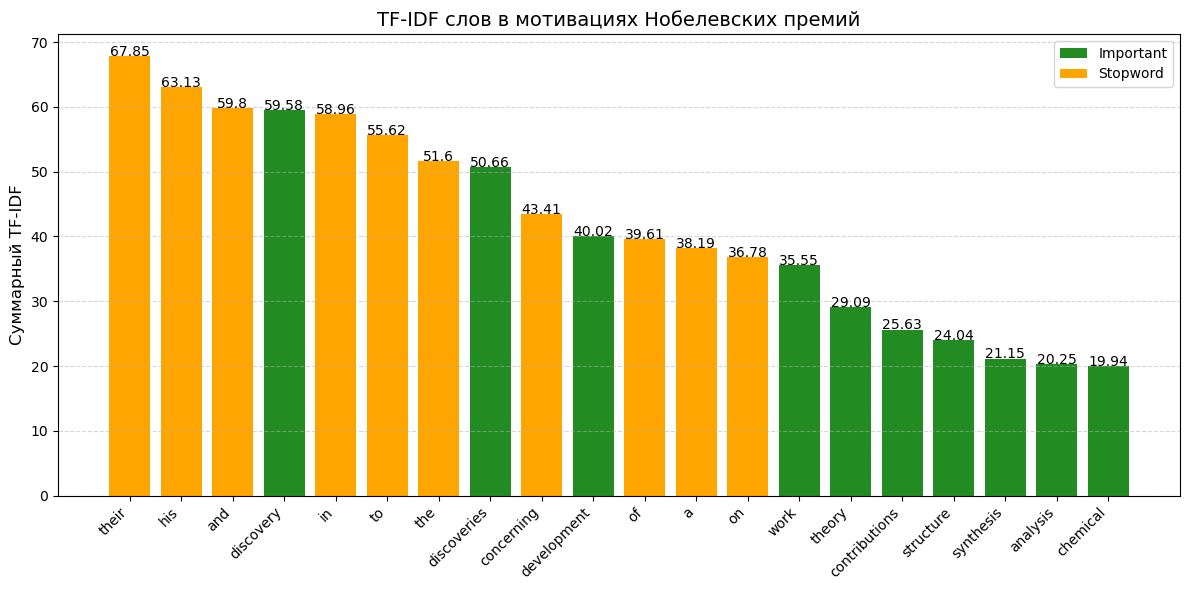

In [40]:
from matplotlib.patches import Patch

word_scores = {}  
for word, score in top10_tfidf:
    word_scores[word] = (score, 'Important')

for word, score in top10_stopwords_tfidf:
    if word not in word_scores: 
        word_scores[word] = (score, 'Stopword')

# Сортируем по суммарному TF-IDF и берём топ-20
sorted_words = sorted(word_scores.items(), key=lambda x: x[1][0], reverse=True)[:20]
words = [w[0] for w in sorted_words]
scores = [round(w[1][0], 2) for w in sorted_words]  # округляем до 2 знаков, чтобы поместилось в график
groups = [w[1][1] for w in sorted_words]

# Цвета для групп
color_map = {'Important': 'forestgreen', 'Stopword': 'orange'}
colors = [color_map[g] for g in groups]

# Рисуем график
plt.figure(figsize=(12,6))
bars = plt.bar(words, scores, color=colors)
plt.title("TF-IDF слов в мотивациях Нобелевских премий", fontsize=14)
plt.ylabel("Суммарный TF-IDF", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Подписи значений сверху столбиков
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score}', ha='center', fontsize=10)

# Легенда
legend_elements = [Patch(facecolor='forestgreen', label='Important'),
                   Patch(facecolor='orange', label='Stopword')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()
